In [22]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/ecommerce_sales_cleaned.csv")

df.head()


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1.0,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1.0,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1.0,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1.0,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1.0,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [23]:
df.shape

(4851, 17)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4851 entries, 0 to 4850
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            4851 non-null   str    
 1   customer_id         4851 non-null   str    
 2   product_id          4851 non-null   str    
 3   category            4851 non-null   str    
 4   price               4851 non-null   float64
 5   discount            4851 non-null   float64
 6   quantity            4851 non-null   float64
 7   payment_method      4851 non-null   str    
 8   order_date          4851 non-null   str    
 9   delivery_time_days  4851 non-null   int64  
 10  region              4851 non-null   str    
 11  returned            4851 non-null   str    
 12  total_amount        4851 non-null   float64
 13  shipping_cost       4851 non-null   float64
 14  profit_margin       4851 non-null   float64
 15  customer_age        4851 non-null   int64  
 16  customer_gender  

In [25]:
numeric_cols = df.select_dtypes(include=np.number).columns

stats = df[numeric_cols].agg(
    ['mean', 'median', 'std', 'var', 'skew', 'kurt']
).T

stats

,mean,median,std,var,skew,kurt
price,91.296755,46.98,99.351478,9870.716139,1.209342,0.116130
discount,0.048804,0.00,0.066925,0.004479,1.280209,0.652161
quantity,1.458978,1.00,0.799399,0.639038,1.521657,0.894438
delivery_time_days,4.814471,5.00,1.245116,1.550314,0.580022,0.094708
total_amount,116.769270,58.35,128.375264,16480.208417,1.188666,0.021557
shipping_cost,6.175149,6.11,2.387844,5.701798,0.096216,-0.334747
profit_margin,21.773065,10.69,26.621829,708.721766,1.208962,0.268885
customer_age,43.749536,44.00,15.018289,225.549008,-0.019338,-1.200336


In [26]:
mode_values = df[numeric_cols].mode().T

mode_values

,0
price,310.3575
discount,0.0000
quantity,1.0000
delivery_time_days,4.0000
total_amount,392.7500
shipping_cost,6.5400
profit_margin,83.8800
customer_age,43.0000


In [27]:
from scipy import stats

sales = df["total_amount"].dropna()

mean_sales = sales.mean()

confidence_interval = stats.t.interval(
    0.95,
    len(sales) - 1,
    loc=mean_sales,
    scale=stats.sem(sales)
)

mean_sales, confidence_interval

(np.float64(116.76927025355596),
 (np.float64(113.15581901087324), np.float64(120.38272149623867)))

In [28]:
df["returned"].value_counts()

returned
No     4602
Yes     249
Name: count, dtype: int64

In [29]:
returned_no = df[df["returned"] == "No"]["total_amount"].dropna()
returned_yes = df[df["returned"] == "Yes"]["total_amount"].dropna()

t_stat, p_value = stats.ttest_ind(
    returned_no,
    returned_yes,
    equal_var=False
)

t_stat, p_value

(np.float64(-3.627079825411537), np.float64(0.00034204792843171925))

In [30]:
table = pd.crosstab(df["category"], df["returned"])

chi2, p_value, dof, expected = stats.chi2_contingency(table)

chi2, p_value

(np.float64(56.184587052917216), np.float64(2.67122635860783e-10))

In [31]:
groups = [
    group["total_amount"].dropna()
    for _, group in df.groupby("category")
]

anova_result = stats.f_oneway(*groups)

anova_result

F_onewayResult(statistic=np.float64(790.1208631863792), pvalue=np.float64(0.0))

In [32]:
correlation = df[numeric_cols].corr()

correlation

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
price,1.000000,-0.021726,-0.014498,-0.015011,0.916154,0.774806,0.791584,-0.005545
discount,-0.021726,1.000000,-0.004386,0.019235,-0.064768,-0.066521,-0.076083,0.016462
quantity,-0.014498,-0.004386,1.000000,0.000327,0.273342,0.278388,0.342420,-0.016021
delivery_time_days,-0.015011,0.019235,0.000327,1.000000,-0.013303,-0.004034,-0.013118,0.005597
total_amount,0.916154,-0.064768,0.273342,-0.013303,1.000000,0.816631,0.896833,-0.012519
shipping_cost,0.774806,-0.066521,0.278388,-0.004034,0.816631,1.000000,0.758414,-0.011552
profit_margin,0.791584,-0.076083,0.342420,-0.013118,0.896833,0.758414,1.000000,-0.002327
customer_age,-0.005545,0.016462,-0.016021,0.005597,-0.012519,-0.011552,-0.002327,1.000000


In [33]:
df["order_date"] = pd.to_datetime(df["order_date"])

monthly_sales = (
    df.set_index("order_date")["total_amount"]
      .resample("MS")
      .sum()
)

monthly_sales

order_date
2023-09-01    14583.27
2023-10-01    24301.62
2023-11-01    20894.68
2023-12-01    28102.59
2024-01-01    20093.29
2024-02-01    20352.02
2024-03-01    23710.34
2024-04-01    23317.61
2024-05-01    26466.26
2024-06-01    19472.77
2024-07-01    20265.24
2024-08-01    23154.95
2024-09-01    20144.58
2024-10-01    24663.38
2024-11-01    22588.35
2024-12-01    24705.62
2025-01-01    21471.24
2025-02-01    24659.99
2025-03-01    24102.30
2025-04-01    24216.09
2025-05-01    28217.66
2025-06-01    23616.76
2025-07-01    27763.12
2025-08-01    26266.51
2025-09-01     9317.49
Freq: MS, Name: total_amount, dtype: float64

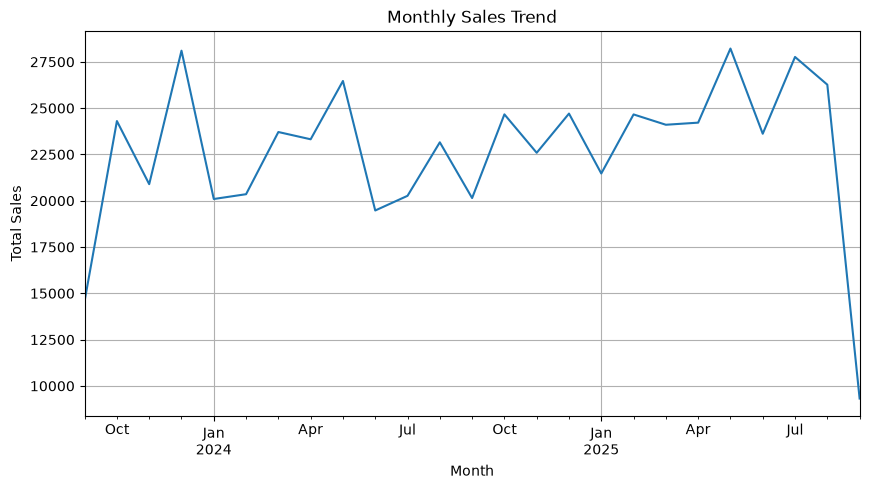

In [34]:
import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(10, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

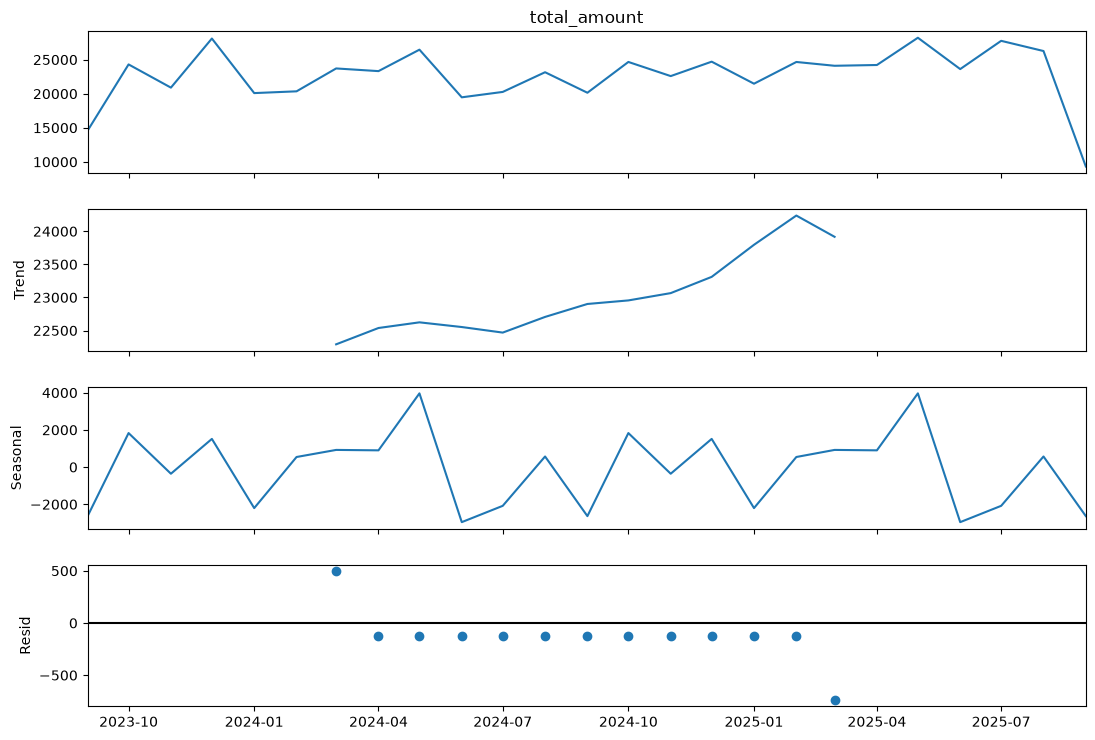

In [37]:
fig = decomposition.plot()
fig.set_size_inches(12, 8)

plt.show()

In [38]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(monthly_sales.dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.925414381914362
p-value: 3.1112208554185365e-05


C:\Users\DELL\AppData\Local\Temp\ipykernel_6596\2428977740.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(monthly_sales.dropna())


In [39]:
moving_average = monthly_sales.rolling(window=3).mean()

moving_average

order_date
2023-09-01             NaN
2023-10-01             NaN
2023-11-01    19926.523333
2023-12-01    24432.963333
2024-01-01    23030.186667
2024-02-01    22849.300000
2024-03-01    21385.216667
2024-04-01    22459.990000
2024-05-01    24498.070000
2024-06-01    23085.546667
2024-07-01    22068.090000
2024-08-01    20964.320000
2024-09-01    21188.256667
2024-10-01    22654.303333
2024-11-01    22465.436667
2024-12-01    23985.783333
2025-01-01    22921.736667
2025-02-01    23612.283333
2025-03-01    23411.176667
2025-04-01    24326.126667
2025-05-01    25512.016667
2025-06-01    25350.170000
2025-07-01    26532.513333
2025-08-01    25882.130000
2025-09-01    21115.706667
Freq: MS, Name: total_amount, dtype: float64

In [40]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

fit = model.fit()

forecast = fit.forecast(6)

forecast

2025-10-01    25644.062637
2025-11-01    22903.302262
2025-12-01    27563.322246
2026-01-01    21943.497708
2026-02-01    23668.142710
2026-03-01    25066.940865
Freq: MS, dtype: float64

In [41]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(monthly_sales, order=(1, 1, 1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(6)

arima_forecast

2025-10-01    10296.048330
2025-11-01    11138.577124
2025-12-01    11863.985867
2026-01-01    12488.555435
2026-02-01    13026.303496
2026-03-01    13489.299120
Freq: MS, Name: predicted_mean, dtype: float64

In [42]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(monthly_sales, order=(1, 1, 1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(6)

arima_forecast

2025-10-01    10296.048330
2025-11-01    11138.577124
2025-12-01    11863.985867
2026-01-01    12488.555435
2026-02-01    13026.303496
2026-03-01    13489.299120
Freq: MS, Name: predicted_mean, dtype: float64

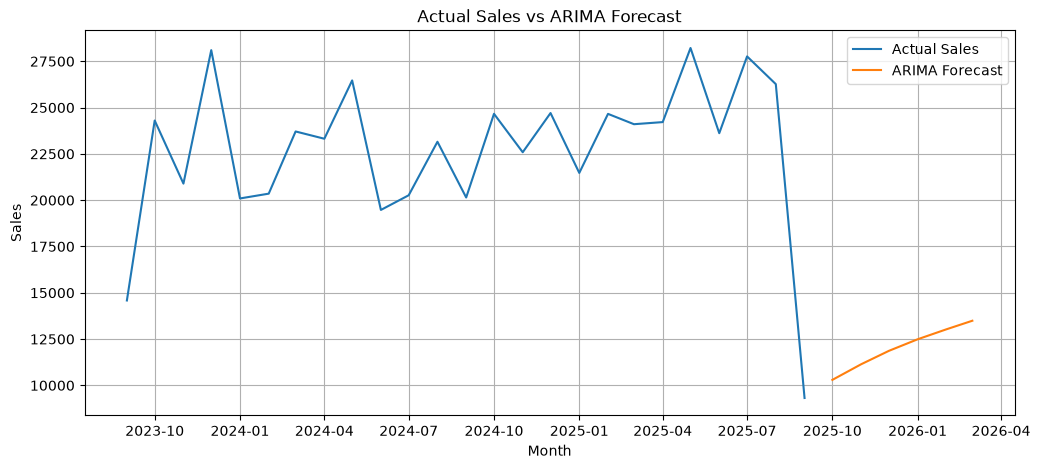

In [43]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_sales, label="Actual Sales")
plt.plot(arima_forecast, label="ARIMA Forecast")

plt.title("Actual Sales vs ARIMA Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

customer_df = df.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "nunique"),
    monetary=("total_amount", "sum"),
    quantity=("quantity", "sum")
).reset_index()

customer_df.head()

,customer_id,recency,frequency,monetary,quantity
0,C10001,194,2,598.51,5.0
1,C10002,530,1,11.21,1.0
2,C10003,93,1,1.03,1.0
3,C10004,600,1,34.41,3.0
4,C10005,210,1,107.31,1.0


In [45]:
from sklearn.preprocessing import StandardScaler

features = ["recency", "frequency", "monetary", "quantity"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(customer_df[features])

X_scaled[:5]

array([[-0.61664395,  1.03605358,  2.70629147,  2.31188053],
       [ 0.9911477 , -0.5684185 , -0.90293522, -0.74601231],
       [-1.09993846, -0.5684185 , -0.96549597, -0.74601231],
       [ 1.32610429, -0.5684185 , -0.76036062,  0.78293411],
       [-0.54008244, -0.5684185 , -0.31235683, -0.74601231]])

In [46]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
silhouette_scores = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

print("Inertia:", inertias)
print("Silhouette Scores:", silhouette_scores)

Inertia: [9090.14500727376, 6937.216327425548, 5829.208604826776, 4792.211799813413, 4320.364929565077, 3913.154399409145, 3583.3501390337324]
Silhouette Scores: [0.39240539462293317, 0.30719241846489304, 0.3138200041254086, 0.34904767160885536, 0.3573725957233431, 0.35247038170172434, 0.3645557026348688]


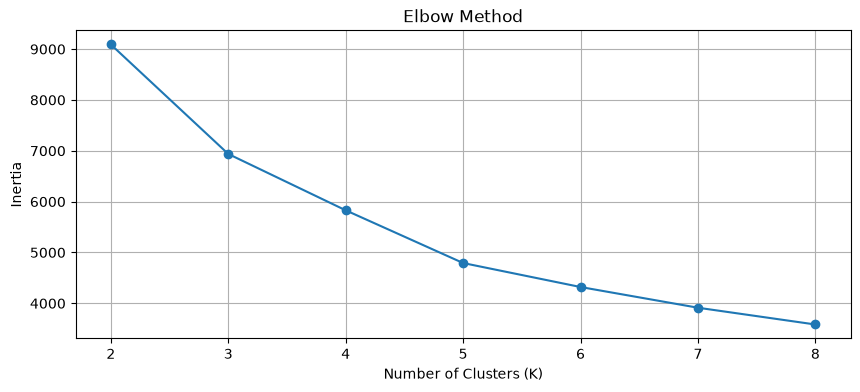

In [47]:
plt.figure(figsize=(10, 4))

plt.plot(range(2, 9), inertias, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

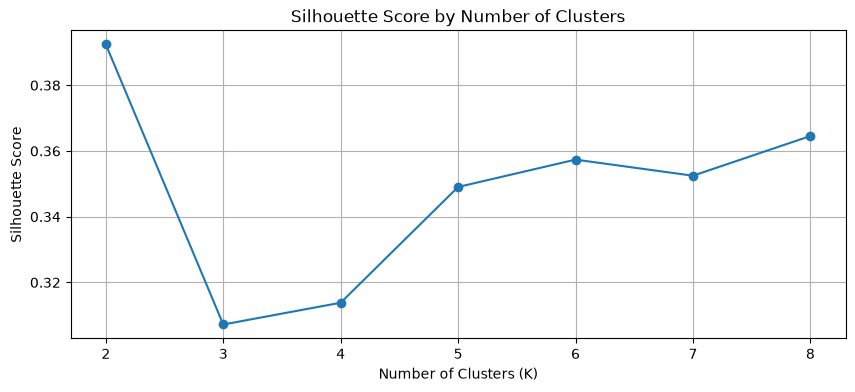

In [48]:
plt.figure(figsize=(10, 4))

plt.plot(range(2, 9), silhouette_scores, marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [49]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

customer_df["cluster"] = kmeans.fit_predict(X_scaled)

customer_df.head()

,customer_id,recency,frequency,monetary,quantity,cluster
0,C10001,194,2,598.51,5.0,0
1,C10002,530,1,11.21,1.0,4
2,C10003,93,1,1.03,1.0,1
3,C10004,600,1,34.41,3.0,4
4,C10005,210,1,107.31,1.0,1


In [50]:
cluster_summary = customer_df.groupby("cluster")[features].mean().round(2)

cluster_summary

,recency,frequency,monetary,quantity
cluster,,,,
0,207.86,2.67,444.41,4.90
1,175.71,1.00,68.58,1.37
2,208.32,2.08,128.12,2.72
3,328.91,1.21,382.06,2.01
4,548.47,1.02,69.17,1.37


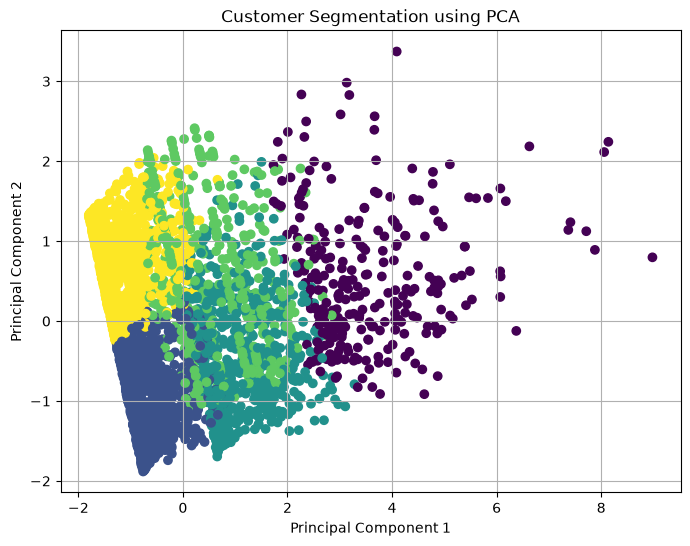

In [51]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_df["cluster"])
plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

In [52]:
df['returned'].value_counts()

returned
No     4602
Yes     249
Name: count, dtype: int64

In [54]:
X = df.drop(columns=["returned", "order_date"])
y = df["returned"]

X = pd.get_dummies(X, drop_first=True)

X = X.fillna(0)

X.head()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age,order_id_O100001,order_id_O100002,...,payment_method_Debit Card,payment_method_PayPal,payment_method_UPI,payment_method_Wallet,region_East,region_North,region_South,region_West,customer_gender_Male,customer_gender_Other
0,164.08,0.15,1.0,4,139.47,7.88,31.17,60,False,False,...,False,False,False,False,False,False,False,True,False,False
1,24.73,0.00,1.0,6,24.73,4.60,-2.62,37,True,False,...,False,False,False,False,False,False,True,False,True,False
2,175.58,0.05,1.0,4,166.80,6.58,13.44,34,False,True,...,False,False,False,False,False,True,False,False,True,False
3,63.67,0.00,1.0,6,63.67,5.50,2.14,21,False,False,...,False,False,True,False,False,False,True,False,False,False
4,16.33,0.15,1.0,6,13.88,2.74,1.15,39,False,False,...,False,False,False,False,True,False,False,False,True,False


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((3880, 13057), (971, 13057))

In [56]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_predictions = log_model.predict(X_test)

log_predictions[:10]

c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array(['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No'],
      dtype=object)

In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, log_predictions))
print("Precision:", precision_score(y_test, log_predictions, pos_label="Yes"))
print("Recall:", recall_score(y_test, log_predictions, pos_label="Yes"))
print("F1 Score:", f1_score(y_test, log_predictions, pos_label="Yes"))
print("ROC-AUC:", roc_auc_score(
    (y_test == "Yes").astype(int),
    log_model.predict_proba(X_test)[:, 1]
))

Accuracy: 0.9485066941297632
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


ROC-AUC: 0.6029533116178066


In [58]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

tree_predictions[:10]

array(['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No'],
      dtype=object)

In [59]:
print("Accuracy:", accuracy_score(y_test, tree_predictions))
print("Precision:", precision_score(y_test, tree_predictions, pos_label="Yes"))
print("Recall:", recall_score(y_test, tree_predictions, pos_label="Yes"))
print("F1 Score:", f1_score(y_test, tree_predictions, pos_label="Yes"))

Accuracy: 0.9485066941297632
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [60]:
importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.head(10)

customer_id_C17860    0.211394
shipping_cost         0.151854
product_id_P232206    0.110334
product_id_P221294    0.110215
order_id_O102836      0.110097
order_id_O102193      0.102137
order_id_O104260      0.102036
order_id_O103801      0.101934
product_id_P203055    0.000000
product_id_P203051    0.000000
dtype: float64

In [62]:
X_reg = df.drop(columns=["total_amount", "order_date", "returned"])
y_reg = df["total_amount"]

X_reg = pd.get_dummies(X_reg, drop_first=True)
X_reg = X_reg.fillna(0)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_reg_train, y_reg_train)

reg_predictions = reg_model.predict(X_reg_test)

reg_predictions[:10]

array([384.1429623 ,  43.15271489, 395.09907506,  24.33129475,
        10.93093214, 452.62505692,  76.3743417 , 237.36925397,
        22.42656178, 143.55924858])

In [63]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_reg_test, reg_predictions)
mae = mean_absolute_error(y_reg_test, reg_predictions)
rmse = np.sqrt(mean_squared_error(y_reg_test, reg_predictions))

print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R² Score: 0.9556409449124879
MAE: 18.021553848555037
RMSE: 27.05208943581174


In [64]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, log_predictions),
        accuracy_score(y_test, tree_predictions)
    ],
    "Precision": [
        precision_score(y_test, log_predictions, pos_label="Yes"),
        precision_score(y_test, tree_predictions, pos_label="Yes")
    ],
    "Recall": [
        recall_score(y_test, log_predictions, pos_label="Yes"),
        recall_score(y_test, tree_predictions, pos_label="Yes")
    ],
    "F1 Score": [
        f1_score(y_test, log_predictions, pos_label="Yes"),
        f1_score(y_test, tree_predictions, pos_label="Yes")
    ]
})

results.round(3)

c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.949,0.0,0.0,0.0
1,Decision Tree,0.949,0.0,0.0,0.0
